# Lecture pour entrainement pandas


In [1]:

import networkx as nx
import stats
from networkx.relabel import relabel_nodes
from importlib import reload
import copy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from model import RandomNetwork, ManualNetwork
from controller import Simulation


from sklearn.compose import make_column_transformer

from core_periphery import *
import copy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from jedi.inference.helpers import deep_ast_copy
import networkx as nx

from model import RandomNetwork, ManualNetwork, UniformShockDistribution, BetaShockDistribution, TargetedShockDistribution
from controller import Simulation
from core_periphery import create_core_periphery_network


In [ ]:
stats.gamma.rvs(a=1, scale=1)

> ## Different mesure for resilience of the network

In [2]:
# Reseau core-periphery bizarre
number_bank = 100
n_core = int(number_bank /2)
n_periphery = number_bank - n_core


In [12]:
probabilities = np.arange(0.1, 1.1, 0.1)
#core_periphery_network = create_core_periphery_network(n_core, n_periphery, p_core=0.7, p_periphery=0.3)
plot_probabilities = {}
mesure_centralite = {}
keeping_track_of_default = np.array([0]*number_bank)
for probability in probabilities:
    network_random = RandomNetwork(number_bank, probability)
    network_random_copy = copy.deepcopy(network_random)
    G = nx.from_numpy_array(network_random.matrix_obligation, create_using=nx.DiGraph)
    # Calculer les centralités
    degree_centrality = nx.out_degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G,weight=None)
    eigenvector_centrality = nx.eigenvector_centrality(G, weight=None)
    mesure_centralite[probability] = (degree_centrality, betweenness_centrality, eigenvector_centrality)

    #network_manual = ManualNetwork(P, c, b)

    default_count_vector = []
    shock_measure_vector = []

    #vector_outside_asset = np.copy(core_periphery_network.get_vector_outside_assets())
    vector_outside_asset = np.copy(network_random.get_vector_outside_assets())
    shock_vector = np.array([0]*number_bank)

    #print("Matrix of obligation: ", network_random.matrix_obligation)
    #print("Vector of outside assets: ", core_periphery_network.vector_outside_asset)
    #print("Net worth: ", core_periphery_network.net_worth)
    #print("vector of outside liabilities: ", core_periphery_network.vector_outside_liabilities)
    for k in range(101):
        shock_vector = k*vector_outside_asset/100
        #simulation_core_network = Simulation("Eisenberg", network_manual, shock_vector)
        #simulation_core_network = Simulation("Eisenberg", core_periphery_network, shock_vector)
        simulation_core_network = Simulation("Eisenberg",network_random, shock_vector)
        simulation_core_network.model.set_network(network_random_copy)
        if k == 42 and probability == 0.5:
            print("Vector of outside assets: ", np.array(simulation_core_network.model.network.vector_outside_asset, dtype=int))
            print("net worth : ", np.array(simulation_core_network.model.network.net_worth, dtype=int))
            print("Vulnerability external max : ", np.max(simulation_core_network.model.network.vulnerabilities))
            print("Vulnerability external min : ", np.min(simulation_core_network.model.network.vulnerabilities))
            print("Vulnerability external mean : ", np.mean(simulation_core_network.model.network.vulnerabilities))
            print("Vulnerability external std : ", np.std(simulation_core_network.model.network.vulnerabilities))

        _ , shock_measure, default_count, vulnerabilities = simulation_core_network.simulate()
        if k == 40 and probability == 1:
           keeping_track_of_default = simulation_core_network.model.network.default_vector




        #network_manual.set_vector_outside_assets(vector_outside_asset)
        #core_periphery_network.set_vector_outside_assets(vector_outside_asset)
        #network_random.set_vector_outside_assets(vector_outside_asset)

        shock_measure_vector.append(shock_measure)
        default_count_vector.append(default_count)

    plot_probabilities[probability] = (shock_measure_vector, default_count_vector)


Vector of outside assets:  [1501 1698 1987 1615 1698  487  990 2052  541  722 1404  134  510 1659
  299  642  114 1294  108 1671  707 1541  549  190  167   73  105 2519
  328  154  211   99   14  104 1693  811 1273  586 1367  421  158 2153
 1187  172  455   66  222 2165  832  376  141  498 1879  175  439  128
   79  102  896  774  723  722  105   36  232  171  185  243  791 2512
  185   92 1632  142  279 3409   76   48  102 1188  972  526  122  537
  310  966  365  796  703  961  362  619  199   70   64  165  499  153
  368   45]
net worth :  [  98   89  220  164   88 1280  356  523  117   74    0   65   80   51
  380  123 1128  207  256  166  132  143   73  729  686 2064  577  303
  943  942 1678  530  524 1223   46   67  183  221  194  183  942  120
   66 1282  289 1399 1937  156  394  152 1694  228   17 2204  178 2059
  460  166   10  186   60  285 1197 1238  764  462  848 1548  256  444
 1072 2437   18 1847 2541  138 1519  157  963  340   78 2260  701   95
 1404  115  608   95  233

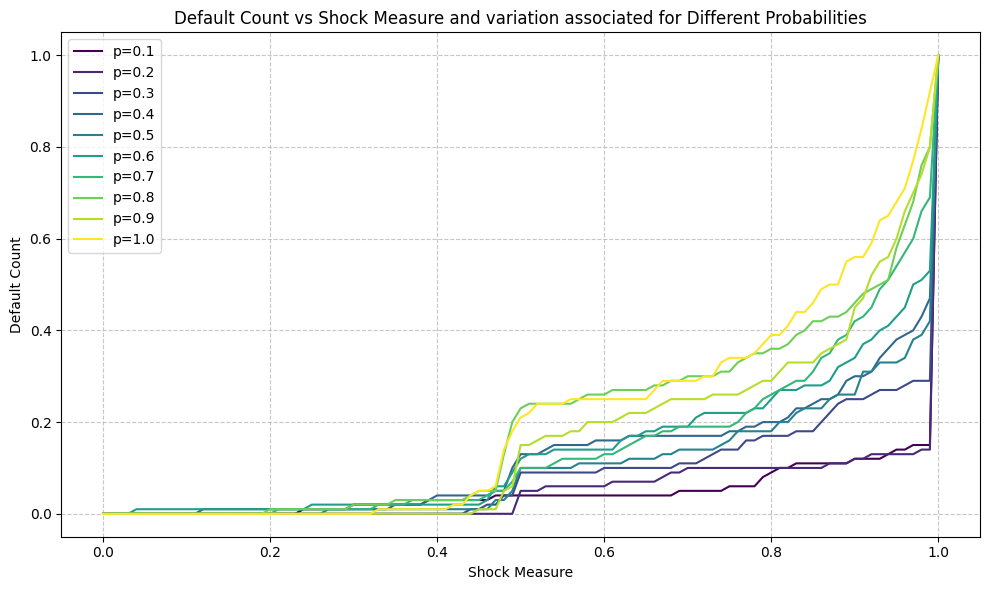

In [13]:

variation_shock_measure_prob = {}
variation_default_count_prob = {}
for probability in probabilities:
    variation_shock_measure_prob[probability] = np.diff(plot_probabilities[probability][0])
    variation_default_count_prob[probability] = np.diff(plot_probabilities[probability][1])


# Créer une figure et un axe
fig, ax = plt.subplots(figsize=(10, 6))

# Créer une palette de couleurs pour distinguer les différentes probabilités
# Plus la probabilité est élevée, plus la couleur sera foncée
colors = plt.cm.viridis(np.linspace(0, 1, len(probabilities)))

# Pour chaque probabilité dans votre dictionnaire
for i, probability in enumerate(probabilities):
    # Récupérer les données pour cette probabilité
    shock_measure_vector, default_count_vector = plot_probabilities[probability]
    variation_default_count = variation_default_count_prob[probability]
    # Tracer la courbe default_count en fonction de shock_measure
    ax.plot(shock_measure_vector, default_count_vector, label=f'p={probability:.1f}',
            color=colors[i], markersize=3, linestyle='-')
    #ax.plot(shock_measure_vector[:100], variation_default_count, label=f'variation for p={probability:.1f}',color=colors[i], linestyle='-')
    #ax.vlines(shock_measure_vector[40], 0, 1, colors='red', linestyles='dashed')

# Ajouter une légende, des titres, etc.
ax.legend()
ax.set_xlabel('Shock Measure')
ax.set_ylabel('Default Count')
ax.set_title('Default Count vs Shock Measure and variation associated for Different Probabilities')

# Ajouter une grille pour faciliter la lecture
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()




In [4]:

betweenness = np.array([mesure_centralite[1][1][k] for k in mesure_centralite[1][1].keys()])
out_degree = np.array([mesure_centralite[1][0][k] for k in mesure_centralite[1][0].keys()])
eigenvector = np.array([mesure_centralite[1][2][k] for k in mesure_centralite[1][2].keys()])
bet_original_indices = np.argsort(betweenness)
out_original_indices = np.argsort(out_degree)
eig_original_indices = np.argsort(eigenvector)


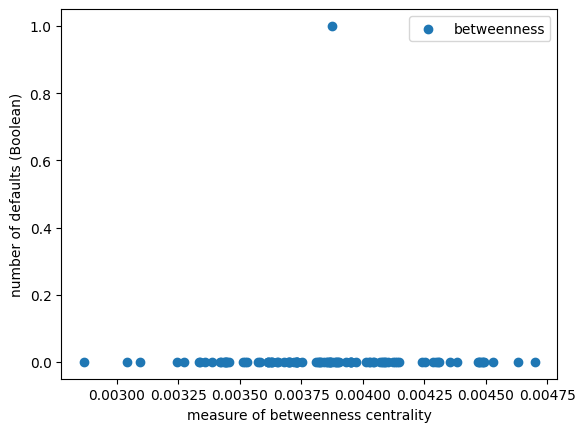

In [5]:
plt.scatter(betweenness[bet_original_indices],keeping_track_of_default[bet_original_indices], label='betweenness')
plt.xlabel("measure of betweenness centrality")
plt.ylabel("number of defaults (Boolean)")
plt.legend()
plt.show()


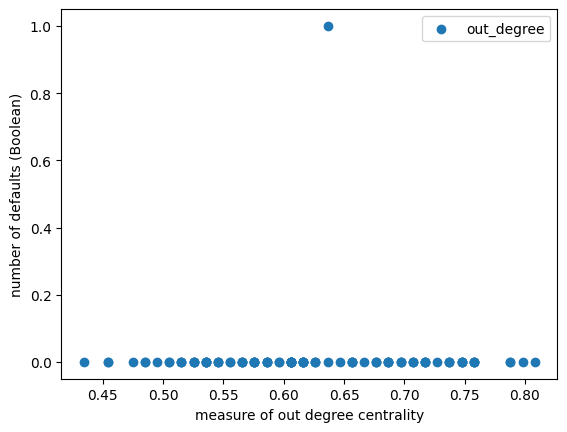

In [6]:
plt.scatter(out_degree[out_original_indices],keeping_track_of_default[out_original_indices], label='out_degree')
plt.xlabel("measure of out degree centrality")
plt.ylabel("number of defaults (Boolean)")
plt.legend()
plt.show()

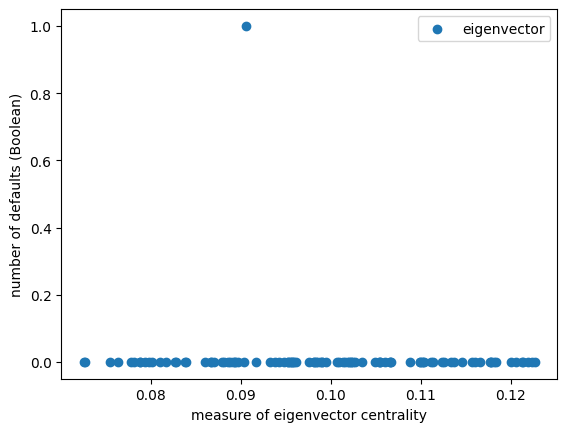

In [7]:
plt.scatter(eigenvector[eig_original_indices],keeping_track_of_default[eig_original_indices], label='eigenvector')
plt.xlabel("measure of eigenvector centrality")
plt.ylabel("number of defaults (Boolean)")
plt.legend()
plt.show()

In [8]:
a = np.array([1.01, 6.0, 21.01])


In [9]:
b = np.array(a, dtype=int)

np.float64(8.498365855987974)

In [481]:
import scipy.stats as stats
stats.gamma.rvs(a=1,scale=100)

np.float64(37.42209507360289)

In [483]:
np.arange(0.1, 1.1, 0.1)[0.7]

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices